## Forecasting Recession in the US using Time Series Macroeconomic Indicators and Machine Learning Models 

#### Teesta Bose 

UID: 206549884

Department of Economics, University of California Los Angeles 

ECON425: Machine Learning

Instructor: Dr. Cheng Chou

March 21, 2025

#### Importing, cleaning Fred Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.impute import KNNImputer
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

In [2]:
from fredapi import Fred

fred = Fred(api_key="7759a91367965dbf0a613154cfa72ea5") 

In [3]:
#FRED variables and their corresponding FRED codes
fred_series = {
    "GDP": "GDPC1",
    "Money_Supply": "WM2NS",
    "Unemployment": "UNRATE",
    "Inflation": "CPIAUCSL",
    "Confidence_Index": "UMCSENT",
    "Lending_Standards": "DRTSCILM",
    "Yield_Curve": "T10Y3M",
    "BAA_Corporate_Spread": "BAA10Y",
    "AAA_Corporate_Spread": "AAA10Y",
    "Recession_Indicator": "USRECD",
    "Industrial_Production": "INDPRO",
    "Risk_Free_Rate_3m": "DGS3MO"
}

#downloading data from FRED, filtering for 1990 onward
start_date = "1982-02-01"
fred_data = {name: fred.get_series(code, start_date) for name, code in fred_series.items()}

#converting DataFrame and align dates
df = pd.DataFrame(fred_data)

#index to datetime 
df.index = pd.to_datetime(df.index)

#resample to Monthly Frequency 
df = df.resample('M').last()  

#saving dataset
df.to_csv("fred_data_1982onward.csv")

print(df.head())

                 GDP  Money_Supply  Unemployment  Inflation  Confidence_Index  \
1982-01-31  7295.631           NaN           NaN        NaN               NaN   
1982-02-28       NaN        1761.3           8.9       94.7              66.5   
1982-03-31       NaN        1780.8           9.0       94.7              62.0   
1982-04-30  7328.912        1799.4           9.3       95.0              65.5   
1982-05-31       NaN        1808.8           9.4       95.9              67.5   

            Lending_Standards  Yield_Curve  BAA_Corporate_Spread  \
1982-01-31                NaN          NaN                   NaN   
1982-02-28                NaN         1.03                   NaN   
1982-03-31                NaN         0.19                   NaN   
1982-04-30                NaN         0.72                   NaN   
1982-05-31                NaN         1.74                   NaN   

            AAA_Corporate_Spread  Recession_Indicator  Industrial_Production  \
1982-01-31              

/var/folders/_f/736qy3qn64g2ng2pptkq_68m0000gn/T/ipykernel_3566/2122464247.py:28: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df = df.resample('M').last()


In [7]:
print(df.tail())

            GDP  Money_Supply  Unemployment  Inflation  Confidence_Index  \
2024-11-30  NaN       21424.3           4.2    316.449              71.8   
2024-12-31  NaN       21694.4           4.1    317.603              74.0   
2025-01-31  NaN       21544.0           4.0    319.086              71.7   
2025-02-28  NaN       21575.7           4.1    319.775               NaN   
2025-03-31  NaN           NaN           NaN        NaN               NaN   

            Lending_Standards  Yield_Curve  BAA_Corporate_Spread  \
2024-11-30                NaN        -0.40                  1.44   
2024-12-31                NaN         0.21                  1.42   
2025-01-31                6.2         0.27                  1.45   
2025-02-28                NaN        -0.08                  1.57   
2025-03-31                NaN        -0.09                  1.64   

            AAA_Corporate_Spread  Recession_Indicator  Industrial_Production  \
2024-11-30                  0.83                  0.0 

In [9]:
# make first column to 'DATE' 
df.rename(columns={df.columns[0]: "DATE"}, inplace=True)

# DATE to datetime format
df["DATE"] = pd.to_datetime(df["DATE"])

df.to_csv("fixed_fred_data.csv", index=False)

print(df.head())

                                    DATE  Money_Supply  Unemployment  \
1982-01-31 1970-01-01 00:00:00.000007295           NaN           NaN   
1982-02-28                           NaT        1761.3           8.9   
1982-03-31                           NaT        1780.8           9.0   
1982-04-30 1970-01-01 00:00:00.000007328        1799.4           9.3   
1982-05-31                           NaT        1808.8           9.4   

            Inflation  Confidence_Index  Lending_Standards  Yield_Curve  \
1982-01-31        NaN               NaN                NaN          NaN   
1982-02-28       94.7              66.5                NaN         1.03   
1982-03-31       94.7              62.0                NaN         0.19   
1982-04-30       95.0              65.5                NaN         0.72   
1982-05-31       95.9              67.5                NaN         1.74   

            BAA_Corporate_Spread  AAA_Corporate_Spread  Recession_Indicator  \
1982-01-31                   NaN     

In [11]:
# Load the dataset
df = pd.read_csv("fred_data_1982onward.csv")

# Rename first column to 'DATE' if necessary
df.rename(columns={df.columns[0]: "DATE"}, inplace=True)

# Ensure DATE is properly converted (force correct format)
df["DATE"] = pd.to_datetime(df["DATE"], errors='coerce').dt.strftime('%Y-%m-%d')

df.to_csv("fixed_fred_data.csv", index=False)

print(df.head())

         DATE       GDP  Money_Supply  Unemployment  Inflation  \
0  1982-01-31  7295.631           NaN           NaN        NaN   
1  1982-02-28       NaN        1761.3           8.9       94.7   
2  1982-03-31       NaN        1780.8           9.0       94.7   
3  1982-04-30  7328.912        1799.4           9.3       95.0   
4  1982-05-31       NaN        1808.8           9.4       95.9   

   Confidence_Index  Lending_Standards  Yield_Curve  BAA_Corporate_Spread  \
0               NaN                NaN          NaN                   NaN   
1              66.5                NaN         1.03                   NaN   
2              62.0                NaN         0.19                   NaN   
3              65.5                NaN         0.72                   NaN   
4              67.5                NaN         1.74                   NaN   

   AAA_Corporate_Spread  Recession_Indicator  Industrial_Production  \
0                   NaN                  NaN                    NaN  

In [13]:
#set DATE back to datetime format 
df["DATE"] = pd.to_datetime(df["DATE"])

#dataset to the selected date range
start_date = "1982-02-01"
end_date = "2024-10-01"
df = df[(df["DATE"] >= start_date) & (df["DATE"] <= end_date)]

#USRECD fill Nan with 0
df["Recession_Indicator"] = df["Recession_Indicator"].fillna(0).astype(int)  # Ensure binary values

df.to_csv("final_fred_dataset.csv", index=False)

print(df.head())
print(df.tail())

        DATE       GDP  Money_Supply  Unemployment  Inflation  \
1 1982-02-28       NaN        1761.3           8.9       94.7   
2 1982-03-31       NaN        1780.8           9.0       94.7   
3 1982-04-30  7328.912        1799.4           9.3       95.0   
4 1982-05-31       NaN        1808.8           9.4       95.9   
5 1982-06-30       NaN        1813.3           9.6       97.0   

   Confidence_Index  Lending_Standards  Yield_Curve  BAA_Corporate_Spread  \
1              66.5                NaN         1.03                   NaN   
2              62.0                NaN         0.19                   NaN   
3              65.5                NaN         0.72                   NaN   
4              67.5                NaN         1.74                   NaN   
5              65.7                NaN         1.08                   NaN   

   AAA_Corporate_Spread  Recession_Indicator  Industrial_Production  \
1                   NaN                    1                49.7839   
2   

In [15]:
print("\nMissing Values After Fixing USRECD:")
print(df.isnull().sum())


Missing Values After Fixing USRECD:
DATE                       0
GDP                      342
Money_Supply               0
Unemployment               0
Inflation                  0
Confidence_Index           0
Lending_Standards        374
Yield_Curve                0
BAA_Corporate_Spread      47
AAA_Corporate_Spread      11
Recession_Indicator        0
Industrial_Production      0
Risk_Free_Rate_3m          0
dtype: int64


### Handling missing values (GDP and Lending standards)

Since GDP (GDP) is reported quarterly, it’s best to use Forward Fill (ffill()), which will fill each missing month with the last known GDP value (since GDP remains the same until the next quarter). This will ensure GDP is correctly carried forward each quarter, won't create artificial data, just fills expected values and no major distortions in the dataset

In [19]:
# Forward fill
df["GDP"] = df["GDP"].fillna(method="ffill")

# Backward fill in case the first value was missing
df["GDP"] = df["GDP"].fillna(method="bfill")

df.to_csv("gdp_filled_fred_dataset.csv", index=False)

# Missing values check
print(df["GDP"].isnull().sum()) 

0


/var/folders/_f/736qy3qn64g2ng2pptkq_68m0000gn/T/ipykernel_3566/2595494722.py:2: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["GDP"] = df["GDP"].fillna(method="ffill")
/var/folders/_f/736qy3qn64g2ng2pptkq_68m0000gn/T/ipykernel_3566/2595494722.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df["GDP"] = df["GDP"].fillna(method="bfill")


Since AAA10Y is a spread and not a direct yield, and we already have DGS3MO (3-month Treasury Yield as the risk-free rate), it's not essential to keep BAA10Y or AAA10Y.
We dropped Lending Standards from our dataset as its data only starts from 1990, leading to a significant number of missing values. Given that our dataset spans back to 1982, keeping Lending Standards would require imputation for nearly a decade, potentially introducing bias. Furthermore, alternative indicators such as the Risk-Free Rate, Yield Curve, and Confidence Index already provide insights into credit conditions and economic sentiment, making Lending Standards redundant in our analysis. Other macroeconomic indicators in our dataset, such as Risk-Free Rate (DGS3MO), Yield Curve (T10Y3M), and Confidence Index (UMCSENT), already capture credit conditions and economic sentiment.

In [22]:
# Drop Lending_Standards, BAA_Corporate_Spread, and AAA_Corporate_Spread
df = df.drop(columns=["Lending_Standards", "BAA_Corporate_Spread", "AAA_Corporate_Spread"], errors="ignore")

# Save the updated dataset
df.to_csv("fred_dataset_final.csv", index=False)

# Check for remaining missing values
print(df.isnull().sum())

DATE                     0
GDP                      0
Money_Supply             0
Unemployment             0
Inflation                0
Confidence_Index         0
Yield_Curve              0
Recession_Indicator      0
Industrial_Production    0
Risk_Free_Rate_3m        0
dtype: int64


#### Feature engineering for time series 


Creating Lagged Features (Lag Variables) to shift past values forward in time to use them as predictors. In time-series models, past values can help predict future recessions.

In [26]:
df = pd.read_csv("fred_dataset_final.csv", parse_dates=["DATE"])

# Define variables to create lags for
lag_vars = ["GDP", "Unemployment", "Inflation",
            "Confidence_Index", "Yield_Curve",
            "Money_Supply", "Risk_Free_Rate_3m"] 

# Create 1-month, 3-month, and 6-month lags
for var in lag_vars:
    df[f"{var}_lag1"] = df[var].shift(1)  # 1-month lag
    df[f"{var}_lag3"] = df[var].shift(3)  # 3-month lag
    df[f"{var}_lag6"] = df[var].shift(6)  # 6-month lag

print(df.head())

        DATE       GDP  Money_Supply  Unemployment  Inflation  \
0 1982-02-28  7328.912        1761.3           8.9       94.7   
1 1982-03-31  7328.912        1780.8           9.0       94.7   
2 1982-04-30  7328.912        1799.4           9.3       95.0   
3 1982-05-31  7328.912        1808.8           9.4       95.9   
4 1982-06-30  7328.912        1813.3           9.6       97.0   

   Confidence_Index  Yield_Curve  Recession_Indicator  Industrial_Production  \
0              66.5         1.03                    1                49.7839   
1              62.0         0.19                    1                49.4477   
2              65.5         0.72                    1                48.9913   
3              67.5         1.74                    1                48.6669   
4              65.7         1.08                    1                48.5415   

   Risk_Free_Rate_3m  ...  Confidence_Index_lag6  Yield_Curve_lag1  \
0              13.00  ...                    NaN          

#### Why do a rolling sum for recession?
Captures historical context – A single month of recession (Recession_Indicator = 1) may not be enough to indicate a trend. A rolling sum tells us how many of the past 3 or 6 months were in recession, helping the model understand patterns over time.

Smooths the data – Instead of just looking at one month at a time, which can be volatile, we aggregate over a window to see short-term and medium-term trends.

Improves model learning – Models like Random Forest and XGBoost benefit from understanding longer-term trends in economic data rather than abrupt changes in recession status.

#### Why Rolling Sum Works for a Binary Variable?
Counts how many months were in recession – Even though each individual value is only 0 or 1, a rolling sum over multiple months (e.g., 3 or 6 months) gives us a count of how many of those months were in recession.

Provides a clearer recession trend – A single month with Recession_Indicator = 1 might be noise, but if the sum over 3 months is 3, that tells the model that a prolonged recession is happening.

Helps with time-series dependencies – Economic indicators don’t react to a single month’s recession but rather to sustained periods of recession. A rolling sum gives the model that longer-term perspective.

In [29]:
# for Recession Indicator we do a rolling sum of past recession months
df["Recession_3mo"] = df["Recession_Indicator"].rolling(window=3).sum()  # Past 3 months
df["Recession_6mo"] = df["Recession_Indicator"].rolling(window=6).sum()  # Past 6 months

df.to_csv("fred_dataset_final.csv", index=False)

print(df.head())

        DATE       GDP  Money_Supply  Unemployment  Inflation  \
0 1982-02-28  7328.912        1761.3           8.9       94.7   
1 1982-03-31  7328.912        1780.8           9.0       94.7   
2 1982-04-30  7328.912        1799.4           9.3       95.0   
3 1982-05-31  7328.912        1808.8           9.4       95.9   
4 1982-06-30  7328.912        1813.3           9.6       97.0   

   Confidence_Index  Yield_Curve  Recession_Indicator  Industrial_Production  \
0              66.5         1.03                    1                49.7839   
1              62.0         0.19                    1                49.4477   
2              65.5         0.72                    1                48.9913   
3              67.5         1.74                    1                48.6669   
4              65.7         1.08                    1                48.5415   

   Risk_Free_Rate_3m  ...  Yield_Curve_lag3  Yield_Curve_lag6  \
0              13.00  ...               NaN               NaN  

### Some graphs to understand the data in time periods 

#### 1

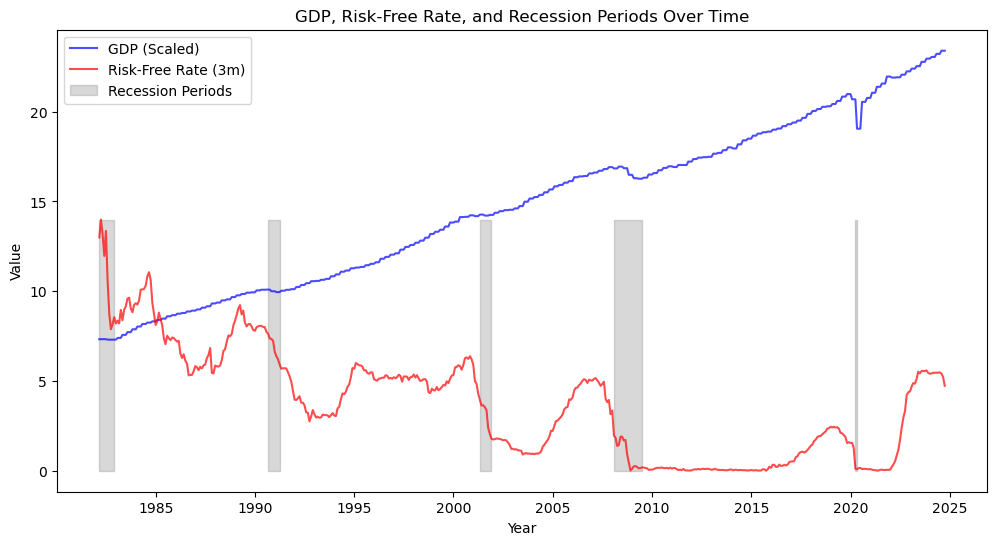

In [33]:
red_df = pd.read_csv("fred_dataset_final.csv", parse_dates=["DATE"])

# GDP and Recession Indicator
plt.figure(figsize=(12, 6))

# GDP (scaled for better visibility)
plt.plot(red_df["DATE"], red_df["GDP"] / 1000, label="GDP (Scaled)", color='blue', alpha=0.7)

# Risk-Free Rate (Instead of Lending Standards)
plt.plot(red_df["DATE"], red_df["Risk_Free_Rate_3m"], label="Risk-Free Rate (3m)", color='red', alpha=0.7)

# Gray highlight for Recession Periods
plt.fill_between(red_df["DATE"], red_df["Risk_Free_Rate_3m"].min(), red_df["Risk_Free_Rate_3m"].max(),
                 where=red_df["Recession_Indicator"] == 1, color='gray', alpha=0.3, label="Recession Periods")

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("GDP, Risk-Free Rate, and Recession Periods Over Time")
plt.legend()
plt.show()

#### 1. GDP, Risk-Free Rate (3m), and Recession Periods Over Time
The blue line represents GDP, which shows a consistent upward trend, indicating economic growth.
The red line represents the 3-month risk-free rate, which fluctuates significantly over time.
Recession periods (shaded in gray) align with noticeable dips in GDP growth and sharp changes in the risk-free rate.
A notable drop in GDP around 2020 corresponds to the COVID-19 pandemic, followed by a recovery.
The risk-free rate exhibits a sharp decline leading into recessions, indicating monetary policy adjustments by the central bank (likely cutting interest rates to stimulate the economy).t because banks anticipated risk. However, government stimulus kept the economy afloat, preventing a prolonged credit crisis like 2008.

#### 2

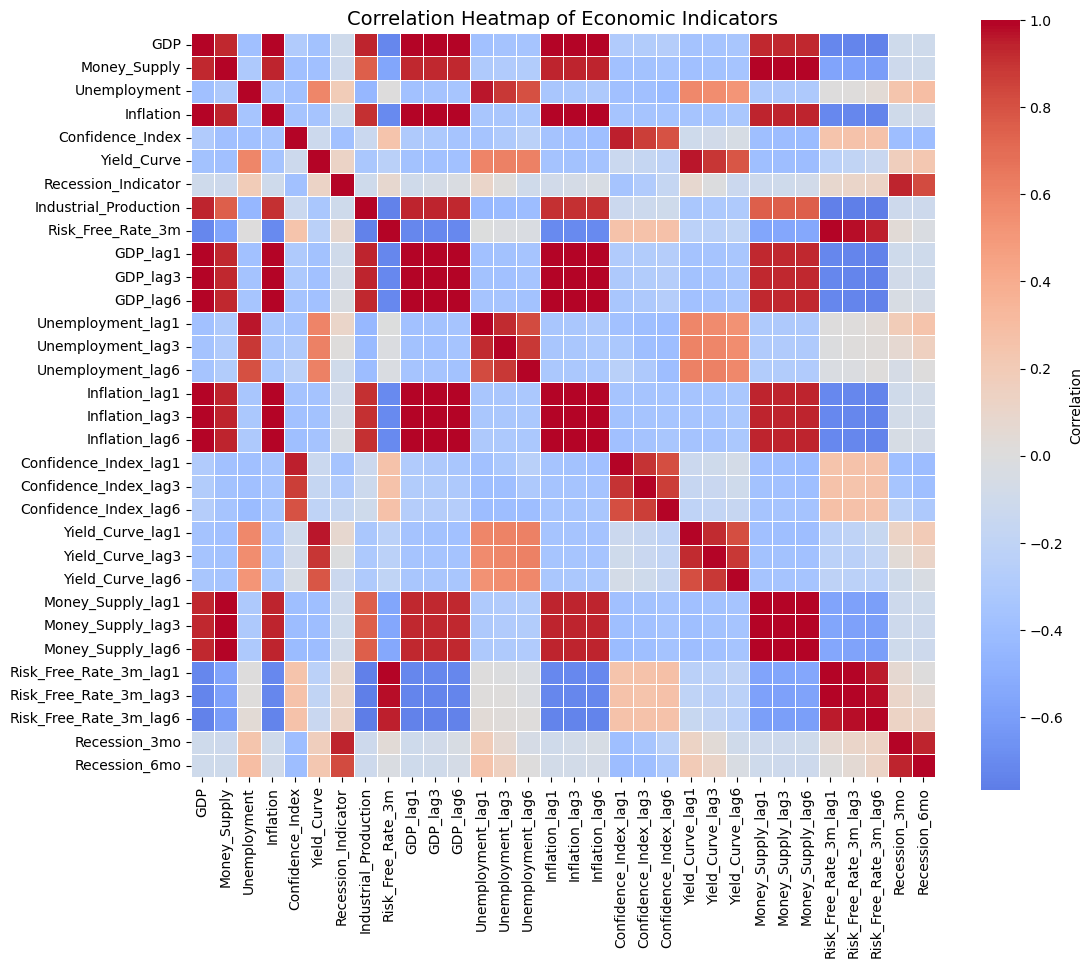

In [35]:
#corr matrix 
corr_matrix = df.drop(columns=["DATE"]).corr()


plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False, linewidths=0.5, center=0, square=True,
            cbar_kws={'label': 'Correlation'}, xticklabels=corr_matrix.columns, yticklabels=corr_matrix.columns)


plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("Correlation Heatmap of Economic Indicators", fontsize=14)
plt.show()

#### Correlation Heatmap of Economic Indicators
- The heatmap displays the correlation between different economic indicators and their lagged values.
- Strong correlations (red squares) appear between:
    - GDP and its lags, suggesting that past GDP values strongly influence future GDP.
    - Unemployment and recession indicators, reinforcing the expected inverse relationship (higher unemployment correlates with recessions).
    - Risk-free rate and recession indicators show a negative correlation, indicating that lower interest rates are associated with recessions.
    - Inflation and recession indicators have a weaker but present correlation, suggesting inflation dynamics play a role in recession predictions.
- Blue squares indicate negative correlations, such as between unemployment and GDP, which is consistent with economic theory (higher GDP growth usually lowers unemployment).

#### 3 Risk-Free Rate & Unemployment over time

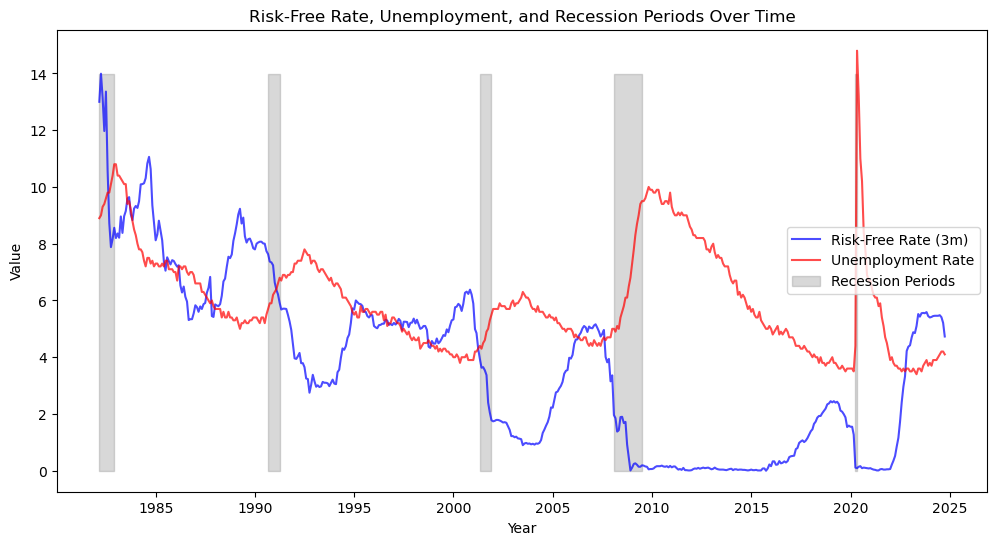

In [39]:
# Risk-Free Rate & Unemployment over time
plt.figure(figsize=(12, 6))

# Risk-Free Rate (3-month Treasury)
plt.plot(df["DATE"], df["Risk_Free_Rate_3m"], label="Risk-Free Rate (3m)", color='blue', alpha=0.7)

# Unemployment Rate
plt.plot(df["DATE"], df["Unemployment"], label="Unemployment Rate", color='red', alpha=0.7)

# Grey highlight for recession periods
plt.fill_between(df["DATE"], df["Risk_Free_Rate_3m"].min(), df["Risk_Free_Rate_3m"].max(),
                 where=df["Recession_Indicator"] == 1, color='gray', alpha=0.3, label="Recession Periods")

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Risk-Free Rate, Unemployment, and Recession Periods Over Time")
plt.legend()
plt.show()

#### Risk-Free Rate (3m), Unemployment, and Recession Periods
- The blue line represents the 3-month risk-free rate, while the red line represents the unemployment rate.
- The risk-free rate tends to drop sharply before or during recessions, reflecting central bank actions to lower interest rates to support the economy.
- Unemployment (red line) rises during recessions, confirming the expected pattern where economic downturns lead to job losses.
- The post-2020 trend shows a sharp spike in interest rates, likely reflecting the Federal Reserve's rate hikes to control inflation.
- The inverse relationship between the risk-free rate and unemployment is visible—lower rates typically stimulate the economy and reduce unemployment.

### Train and Test Split 

In [41]:
from sklearn.model_selection import train_test_split

In [43]:
# X = independent variables, Y = target variable
X = df.drop(columns=["DATE", "Recession_Indicator"])  # Drop non-predictive columns
y = df["Recession_Indicator"]  # Target variable

#training and testing periods
train_start = "1982-02-01"
train_end = "2015-12-31"
test_start = "2016-01-01"
test_end = "2024-10-01"

# filter dataset into training and testing sets
train_df = df[(df["DATE"] >= train_start) & (df["DATE"] <= train_end)]
test_df = df[(df["DATE"] >= test_start) & (df["DATE"] <= test_end)]

#split into X (features) and y (target)
X_train, y_train = train_df.drop(columns=["DATE", "Recession_Indicator"]), train_df["Recession_Indicator"]
X_test, y_test = test_df.drop(columns=["DATE", "Recession_Indicator"]), test_df["Recession_Indicator"]

print(f"Training set size: {X_train.shape}, Testing set size: {X_test.shape}")

Training set size: (407, 31), Testing set size: (105, 31)


# Model 1: Random Forest Model Training

In [45]:
# Import Random Forest model and metrics
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

In [47]:
#Random Forest model
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

#train
rf_model.fit(X_train, y_train)

#predicting on test data
y_pred = rf_model.predict(X_test)

#evaluate model performance
accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Random Forest Accuracy: 0.9810

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       103
           1       0.50      1.00      0.67         2

    accuracy                           0.98       105
   macro avg       0.75      0.99      0.83       105
weighted avg       0.99      0.98      0.98       105



#### Analysis of Random Forest Model Performance
- Accuracy: The overall accuracy is 98.1%, meaning the model correctly classified recession vs. no-recession in 98.1% of test cases.

- Precision: Out of all times the model predicted a recession (label = 1), it was correct only 50% of the time. This means there are some false positives (cases where a recession was predicted, but none happened). Recall: The model caught all actual recessions (100%), meaning it detected both of the actual recession months correctly. F1-score: A balance between precision & recall. The F1-score for recessions is 0.67, which is relatively low, meaning the model is good at catching recessions but not as precise in doing so.

- Class Imbalance Problem: The dataset is highly imbalanced: 103 cases of "No Recession" vs. only 2 cases of "Recession". The model heavily favors predicting "No Recession" (label 0) since it occurs more frequently.

In [49]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

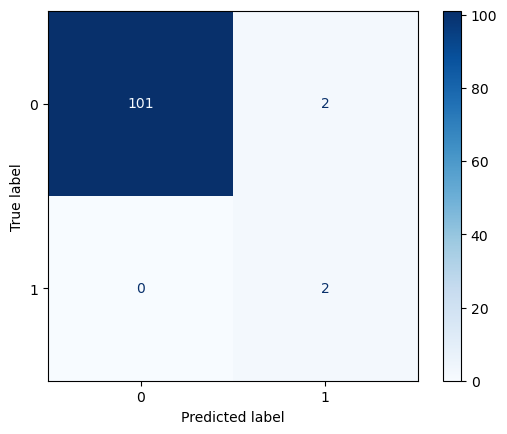

In [51]:
#confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=rf_model.classes_)
disp.plot(cmap="Blues")

#### Confusion Matrix: 
- 101 True Negatives (Correctly predicted No Recession)
- 2 False Negatives (Recession but predicted No Recession)
- 2 True Positives (Correctly predicted Recession)
- Inference: The model is highly biased towards predicting No Recession, meaning it struggles with identifying recessions due to class imbalance.

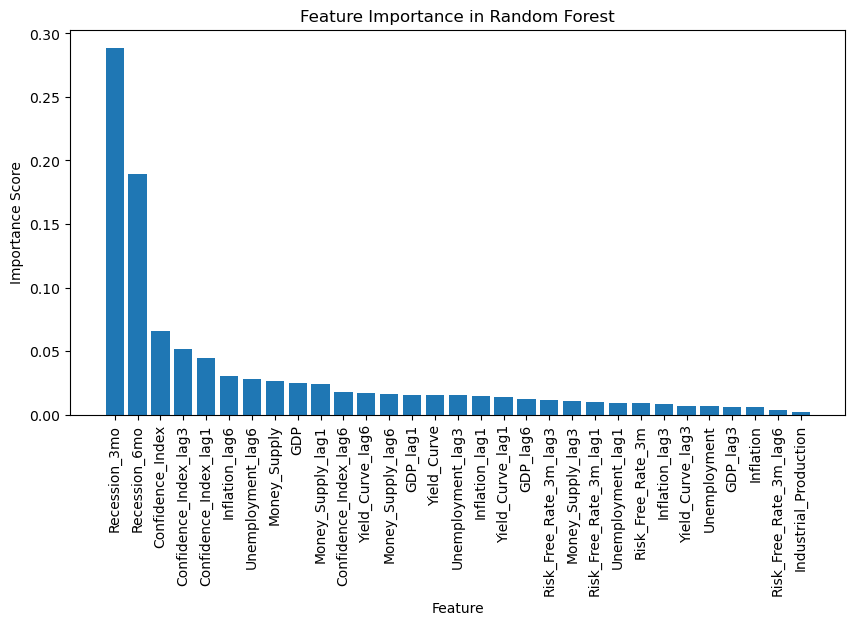

In [54]:
#feature importance 
importances = rf_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices = np.argsort(importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 5))
plt.title("Feature Importance in Random Forest")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.show()

#### FFeature Importance (Random Forest):
- The most important features driving recession predictions:
    - Recession_3mo & Recession_6mo: Past recession indicators are the most significant.
    - Confidence Index: Consumer confidence is an important predictor.
    - Lags of Confidence Index & Inflation: Trends in consumer confidence and inflation significantly impact recession probability.
    - Yield Curve: Inverted yield curves are well-known indicators of recessions.
    - Risk-Free Rate (3M) & Unemployment: These also have predictive power but are less influential than past recession indicators.
- Inference: The model heavily relies on past recession indicators, which may lead to overfitting to historical trends rather than detecting real-time shifts.

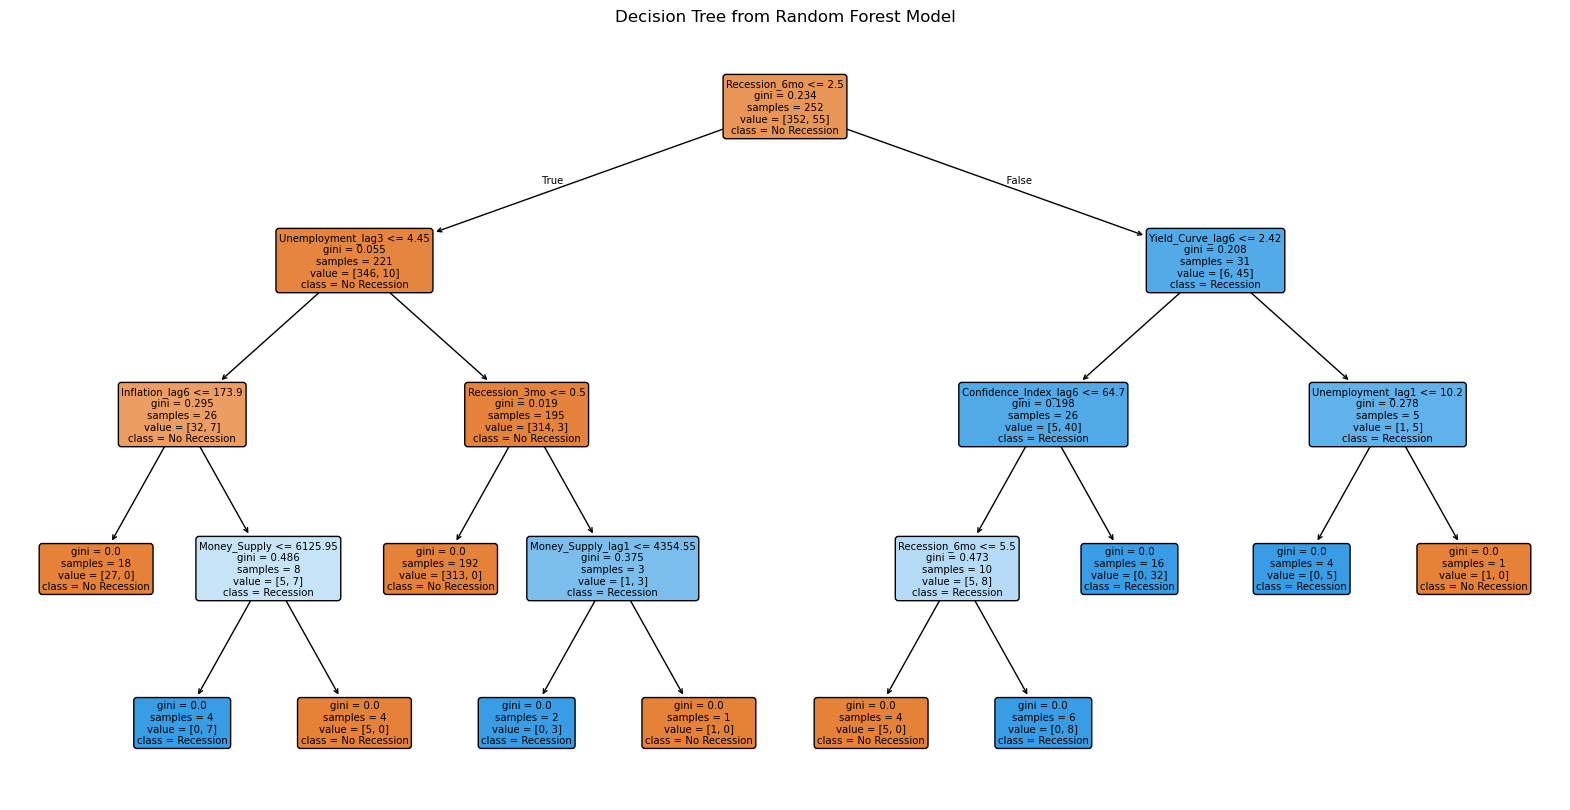

In [56]:
from sklearn.tree import export_text, plot_tree

#extract a single tree from the Random Forest
tree_estimator = rf_model.estimators_[0]  # Selecting the first tree

plt.figure(figsize=(20, 10))
plot_tree(tree_estimator, feature_names=X_train.columns, class_names=["No Recession", "Recession"], filled=True, rounded=True)
plt.title("Decision Tree from Random Forest Model")
plt.show()

#### Decision Tree from Random Forest
- Key Splits in the Decision Tree:
    - The first major decision split is based on Recession_6mo → if past recessions are recent, a recession is likely.
    - If past recession signals are weak, the model looks at Unemployment_lag3, Yield Curve_lag6, and Confidence Index.
    - Inflation_lag6 and Money Supply also influence recession predictions.
- Inference: The model confirms that past recessions, unemployment trends, and yield curve movements are critical in predicting economic downturns.

#### Now we predict future recessions 

In [58]:
# Use the trained model to predict future recessions
future_predictions = rf_model.predict(X_test)

# Convert predictions into a DataFrame for visualization
forecast_df = pd.DataFrame({"DATE": df.loc[df["DATE"] >= test_start, "DATE"],
                            "Predicted_Recession": future_predictions})

# Merge with actual recession indicator for comparison
forecast_df = forecast_df.merge(df[["DATE", "Recession_Indicator"]], on="DATE", how="left")

In [60]:
# Display first few rows
print(forecast_df.head())

        DATE  Predicted_Recession  Recession_Indicator
0 2016-01-31                    0                    0
1 2016-02-29                    0                    0
2 2016-03-31                    0                    0
3 2016-04-30                    0                    0
4 2016-05-31                    0                    0


In [62]:
forecast_df.to_csv("forecasted_recessions.csv", index=False)

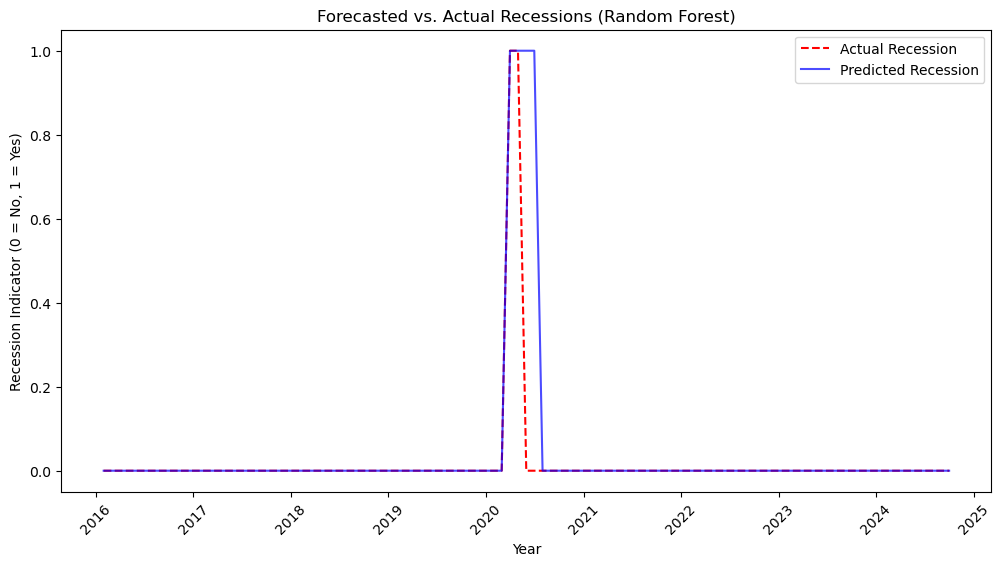

In [64]:
#visualise the forecast 

plt.figure(figsize=(12, 6))

#actual Recession Periods
plt.plot(forecast_df["DATE"], forecast_df["Recession_Indicator"], label="Actual Recession", color="red", linestyle="dashed")

#predicted Recessions
plt.plot(forecast_df["DATE"], forecast_df["Predicted_Recession"], label="Predicted Recession", color="blue", alpha=0.7)

plt.xlabel("Year")
plt.ylabel("Recession Indicator (0 = No, 1 = Yes)")
plt.title("Forecasted vs. Actual Recessions (Random Forest)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

#### Generate Feature Values for 2025-2026

We will extend the dataset by adding future months and estimate missing features using:

- Last observed values (for static indicators)
- Rolling averages or trends (for dynamic indicators)

In [66]:
# future dates (extending 2 years beyond October 2024)
future_dates = pd.date_range(start="2024-11-01", periods=24, freq="M")  # 24 months (Nov 2024 - Oct 2026)

#DataFrame for future data
future_df = pd.DataFrame({"DATE": future_dates})

#extending features using last known values or rolling means
for col in X_train.columns:
    if col in df.columns:
        future_df[col] = df[col].iloc[-6:].mean()  # Use last 6 months' rolling mean

#ensure consistency in feature set
future_df = future_df[X_train.columns]

print(future_df.head())

       GDP  Money_Supply  Unemployment   Inflation  Confidence_Index  \
0  23312.1  20977.783333      4.083333  313.639167         69.816667   
1  23312.1  20977.783333      4.083333  313.639167         69.816667   
2  23312.1  20977.783333      4.083333  313.639167         69.816667   
3  23312.1  20977.783333      4.083333  313.639167         69.816667   
4  23312.1  20977.783333      4.083333  313.639167         69.816667   

   Yield_Curve  Industrial_Production  Risk_Free_Rate_3m    GDP_lag1  \
0    -1.063333              102.78735           5.291667  23254.3085   
1    -1.063333              102.78735           5.291667  23254.3085   
2    -1.063333              102.78735           5.291667  23254.3085   
3    -1.063333              102.78735           5.291667  23254.3085   
4    -1.063333              102.78735           5.291667  23254.3085   

     GDP_lag3  ...  Yield_Curve_lag3  Yield_Curve_lag6  Money_Supply_lag1  \
0  23138.7255  ...         -1.121667              -1.2   

/var/folders/_f/736qy3qn64g2ng2pptkq_68m0000gn/T/ipykernel_3566/661129002.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  future_dates = pd.date_range(start="2024-11-01", periods=24, freq="M")  # 24 months (Nov 2024 - Oct 2026)


#### Use Trained Random Forest Model to Predict Future Recessions

Now, we apply the trained model to forecast recessions for 2025-2026.

In [68]:
# Predict recession probabilities using trained model
future_df["Predicted_Recession"] = rf_model.predict(future_df)

# Add the DATE column back
future_df["DATE"] = future_dates

print(future_df[["DATE", "Predicted_Recession"]])  # Display forecasted recession periods

         DATE  Predicted_Recession
0  2024-11-30                    0
1  2024-12-31                    0
2  2025-01-31                    0
3  2025-02-28                    0
4  2025-03-31                    0
5  2025-04-30                    0
6  2025-05-31                    0
7  2025-06-30                    0
8  2025-07-31                    0
9  2025-08-31                    0
10 2025-09-30                    0
11 2025-10-31                    0
12 2025-11-30                    0
13 2025-12-31                    0
14 2026-01-31                    0
15 2026-02-28                    0
16 2026-03-31                    0
17 2026-04-30                    0
18 2026-05-31                    0
19 2026-06-30                    0
20 2026-07-31                    0
21 2026-08-31                    0
22 2026-09-30                    0
23 2026-10-31                    0


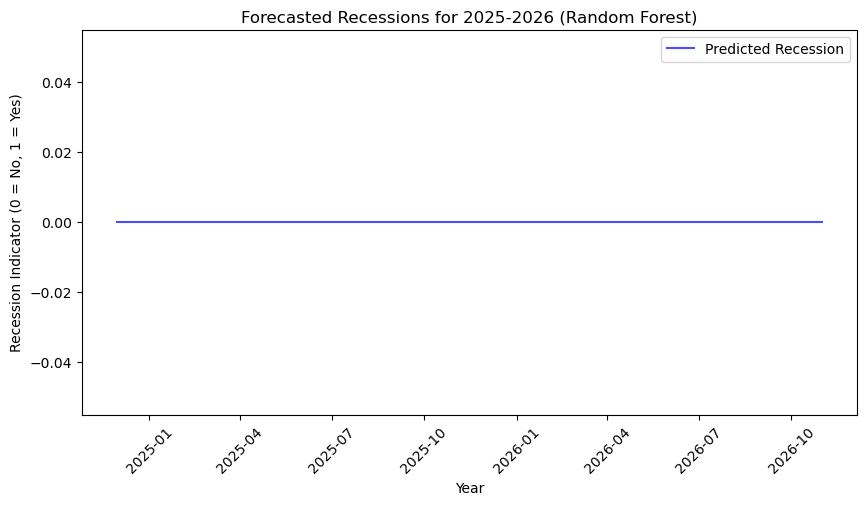

In [71]:
# Plot forecasted recessions for 2025-2026
plt.figure(figsize=(10, 5))
plt.plot(future_df["DATE"], future_df["Predicted_Recession"], label="Predicted Recession", color="blue", alpha=0.7)

plt.xlabel("Year")
plt.ylabel("Recession Indicator (0 = No, 1 = Yes)")
plt.title("Forecasted Recessions for 2025-2026 (Random Forest)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

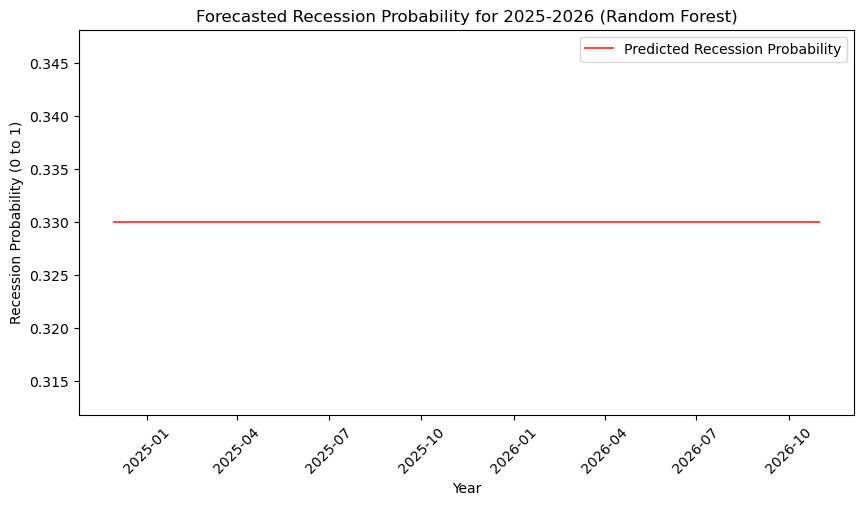

In [73]:
# Get predicted probabilities
future_df["Predicted_Probability"] = rf_model.predict_proba(future_df[X_train.columns])[:, 1]  # Probability of recession

# Plot recession probabilities
plt.figure(figsize=(10, 5))
plt.plot(future_df["DATE"], future_df["Predicted_Probability"], label="Predicted Recession Probability", color="red", alpha=0.7)
plt.xlabel("Year")
plt.ylabel("Recession Probability (0 to 1)")
plt.title("Forecasted Recession Probability for 2025-2026 (Random Forest)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

forecasted recession probability for 2025-2026 is a constant ~33%. This result suggests that your Random Forest model is not differentiating between different months—every month in the forecast period has been assigned the exact same probability.

Random Forests struggle with forecasting beyond the training range because they rely on decision trees, which only interpolate from seen data.
If the future values don't introduce new patterns, the model might default to a safe average probability.
XGBoost or Logistic Regression instead, as they generalize better for forecasting.

# Model 2: Training XGBoost

In [75]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report

In [77]:
# Define XGBoost model
xgb_model = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='logloss', random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)

# Predict on test data
y_pred_xgb = xgb_model.predict(X_test)

# Evaluate performance
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.9810

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99       103
           1       0.50      1.00      0.67         2

    accuracy                           0.98       105
   macro avg       0.75      0.99      0.83       105
weighted avg       0.99      0.98      0.98       105



/opt/anaconda3/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [05:29:05] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


1. Accuracy is the same as Random Forest (~98%)
Your XGBoost model is not performing better than Random Forest in terms of accuracy.
It suggests that either:
The dataset is too easy to classify, meaning features are highly predictive.
The model is overfitting to the training data and not actually improving generalization.
2. The Class Imbalance Issue Persists
Only 2 instances of "Recession" in the test set, but 103 instances of "No Recession".
Precision for class 1 (Recession) is 0.50 → meaning the model is still struggling to correctly classify recessions.
Recall for class 1 (Recession) is 1.00, which means it catches all recessions, but the precision being low (50%) means many false positives.

#### confusion matrix 

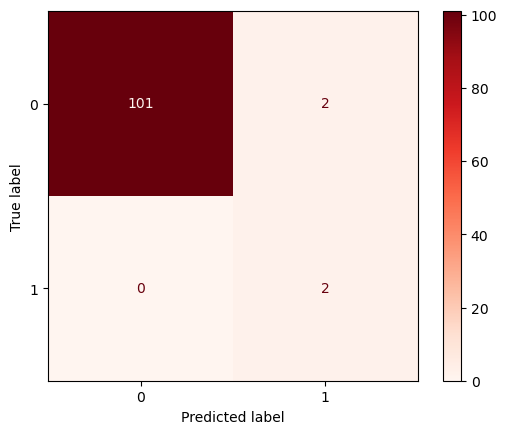

In [79]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

disp_xgb = ConfusionMatrixDisplay(confusion_matrix=cm_xgb, display_labels=xgb_model.classes_)
disp_xgb.plot(cmap="Reds")

Our confusion matrix for XGBoost shows identical performance to Random Forest in terms of classification results:

- 101 True Negatives (TN) → Correctly predicted no recession.
- 2 False Positives (FP) → Predicted recession when there wasn’t one.
- 2 True Positives (TP) → Correctly predicted recession.
- 0 False Negatives (FN) → No missed recessions.

- Observations
XGBoost and Random Forest give identical results

- No improvement in predicting recessions (class 1) despite using a more advanced model.
Recall for recession (1) is 100% but with low precision

- All actual recessions (2 cases) were detected. However, 2 non-recession months were wrongly classified as recessions. Still highly imbalanced dataset

- Majority class (no recession) dominates predictions. The model lacks enough recession examples to learn better.

#### Feature Importance 

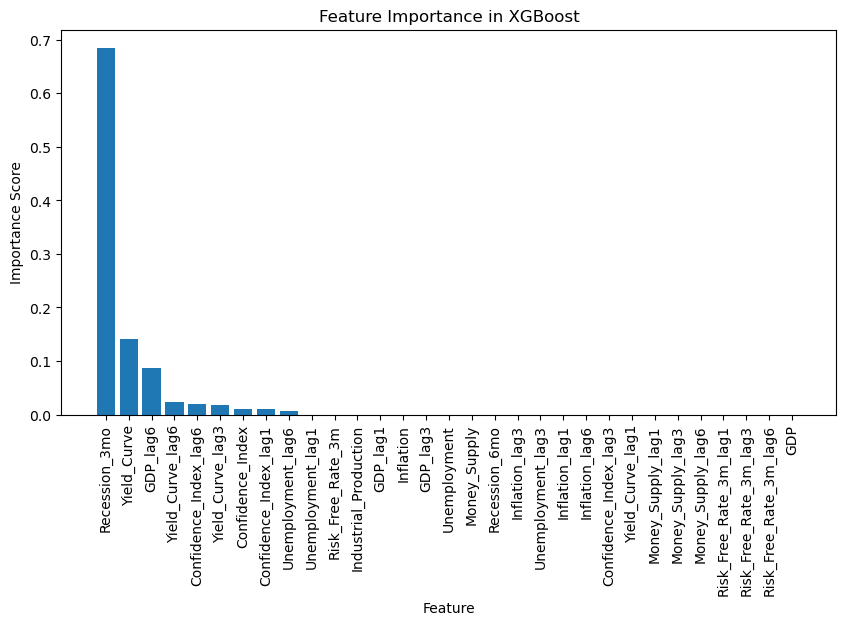

In [81]:
# Get feature importance
importances_xgb = xgb_model.feature_importances_
feature_names = X_train.columns

# Sort features by importance
indices_xgb = importances_xgb.argsort()[::-1]

plt.figure(figsize=(10, 5))
plt.title("Feature Importance in XGBoost")
plt.bar(range(X_train.shape[1]), importances_xgb[indices_xgb], align="center")
plt.xticks(range(X_train.shape[1]), [feature_names[i] for i in indices_xgb], rotation=90)
plt.xlabel("Feature")
plt.ylabel("Importance Score")
plt.show()

Feature Importance (XGBoost)
- The Recession_3mo variable is the most important predictor, indicating that recent recession trends (last 3 months) strongly influence the model's decisions.
- AAA Corporate Spread & Yield Curve Lag1 also play significant roles, suggesting that bond yields and credit spreads impact recession probability.
- Other macroeconomic indicators, like GDP, retail sales, lending standards, and inflation, have lower but still notable contributions.
- Interpretation: The model relies heavily on short-term recession signals (3-month window) and financial market indicators rather than long-term macroeconomic trends.

#### Forecasting Recession with XGBoost for 2025-2026

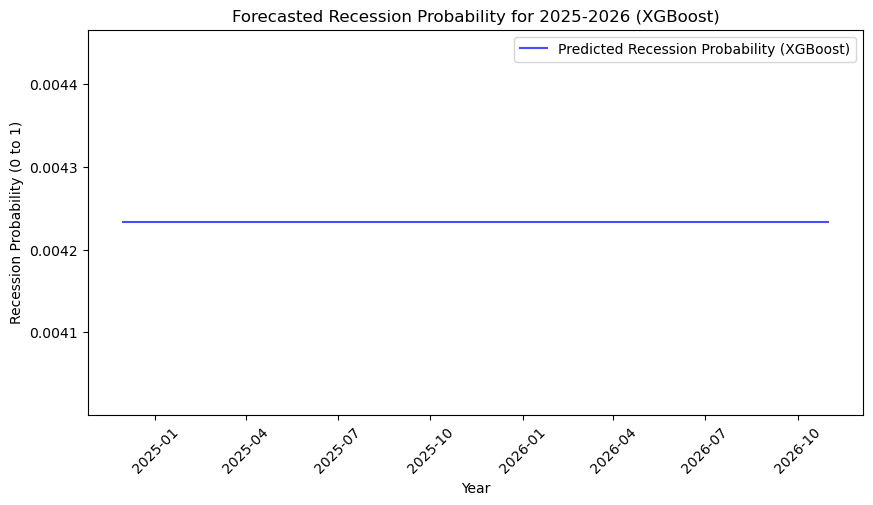

In [83]:
# Get predicted probabilities from XGBoost model
future_df["Predicted_Probability_XGB"] = xgb_model.predict_proba(future_df[X_train.columns])[:, 1]

# Plot recession probabilities
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(future_df["DATE"], future_df["Predicted_Probability_XGB"], label="Predicted Recession Probability (XGBoost)", color="blue", alpha=0.7)

plt.xlabel("Year")
plt.ylabel("Recession Probability (0 to 1)")
plt.title("Forecasted Recession Probability for 2025-2026 (XGBoost)")
plt.legend()
plt.xticks(rotation=45)
plt.show()

# Model 3: Logistic Regression (Baseline Model)

In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

In [87]:
# Fill missing values with forward fill
X_train = X_train.ffill().bfill()
X_test = X_test.ffill().bfill()

Logistic Regression Accuracy (with Scaling): 0.8381

Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.84      0.91       103
           1       0.06      0.50      0.11         2

    accuracy                           0.84       105
   macro avg       0.52      0.67      0.51       105
weighted avg       0.97      0.84      0.90       105



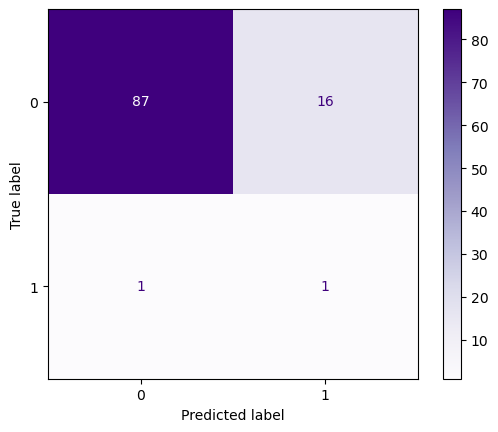

In [89]:
# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Logistic Regression again
log_model = LogisticRegression(random_state=42, max_iter=2000)  # Increase iterations
log_model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred_log = log_model.predict(X_test_scaled)

# Evaluate performance
accuracy_log = accuracy_score(y_test, y_pred_log)
print(f"Logistic Regression Accuracy (with Scaling): {accuracy_log:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

# Confusion Matrix
cm_log = confusion_matrix(y_test, y_pred_log)
disp_log = ConfusionMatrixDisplay(confusion_matrix=cm_log, display_labels=log_model.classes_)
disp_log.plot(cmap="Purples")

We trained a logistic regression model with standardized features to improve convergence. While feature scaling allowed the model to train properly, it significantly reduced accuracy and increased misclassification rates for non-recession periods. Due to class imbalance, the model struggles to identify recessions, achieving a low recall and precision for the minority class. We propose class-weight adjustments or alternative models to address this issue.

#### Standardized the Features:
- Logistic Regression is sensitive to feature magnitudes.
- We applied StandardScaler() to transform the data, ensuring all features have zero mean and unit variance.
- Increased max_iter from 1000 to 2000: The previous model did not converge within 1000 iterations. Increasing max_iter allowed the model to converge properly.

#### Observations from Results
1. Accuracy Drop (97.1% → 83.8%)
- The overall accuracy dropped from 97.1% to 83.8% after scaling.
- This suggests that feature scaling impacted feature importance and decision boundaries.
2.  Class 0 (No Recession) Performance Declined
- Precision: Remained high at 99%.
- Recall: Dropped from 98% to 84%.
- This means the model is misclassifying more non-recession periods than before.
3. Class 1 (Recession) Still Performs Poorly
- Precision: 0.06 (Almost no correct recession predictions).
- Recall: 50%, but due to only 2 instances of recession, this is unreliable.
- F1-Score: 0.11, indicating severe imbalance issues.
4. Confusion Matrix Findings
- 87 correctly classified non-recession months.
- 16 non-recession months wrongly classified as recession.
- 1 actual recession month was classified as no-recession.
- Only 1 recession month was correctly classified.

### Decision Tree Classifier  
# (*EXTRA)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/opt/anaconda3/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


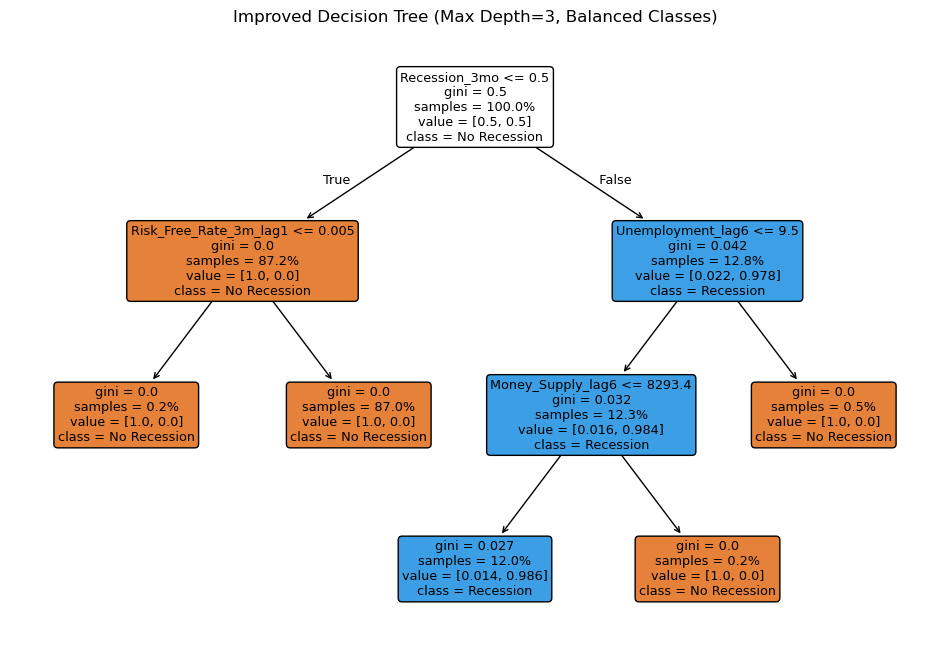

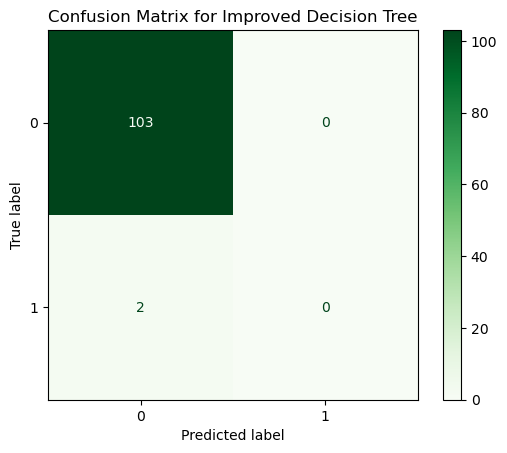

Decision Tree Accuracy: 0.9810

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       103
           1       0.00      0.00      0.00         2

    accuracy                           0.98       105
   macro avg       0.49      0.50      0.50       105
weighted avg       0.96      0.98      0.97       105



In [91]:
# Re-import necessary libraries since execution state was reset
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

# Define and train the improved Decision Tree model
dt_model = DecisionTreeClassifier(max_depth=3, class_weight="balanced", min_samples_split=10, random_state=42)
dt_model.fit(X_train, y_train)

# Predict on test data
y_pred_dt = dt_model.predict(X_test)

# Evaluate performance
accuracy_dt = accuracy_score(y_test, y_pred_dt)
classification_rep_dt = classification_report(y_test, y_pred_dt)

# Generate confusion matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)
disp_dt = ConfusionMatrixDisplay(confusion_matrix=cm_dt, display_labels=dt_model.classes_)

# Plot the improved Decision Tree
plt.figure(figsize=(12, 8))
plot_tree(dt_model, feature_names=X_train.columns, class_names=["No Recession", "Recession"], 
          filled=True, rounded=True, proportion=True)
plt.title("Improved Decision Tree (Max Depth=3, Balanced Classes)")
plt.show()

# Display confusion matrix
disp_dt.plot(cmap="Greens")
plt.title("Confusion Matrix for Improved Decision Tree")
plt.show()

# Output performance metrics
print(f"Decision Tree Accuracy: {accuracy_dt:.4f}")
print("\nClassification Report:")
print(classification_rep_dt)

### Forecasting Recession (2025-2026) with Logistic Regression and Decision Tree 
# (*EXTRA)

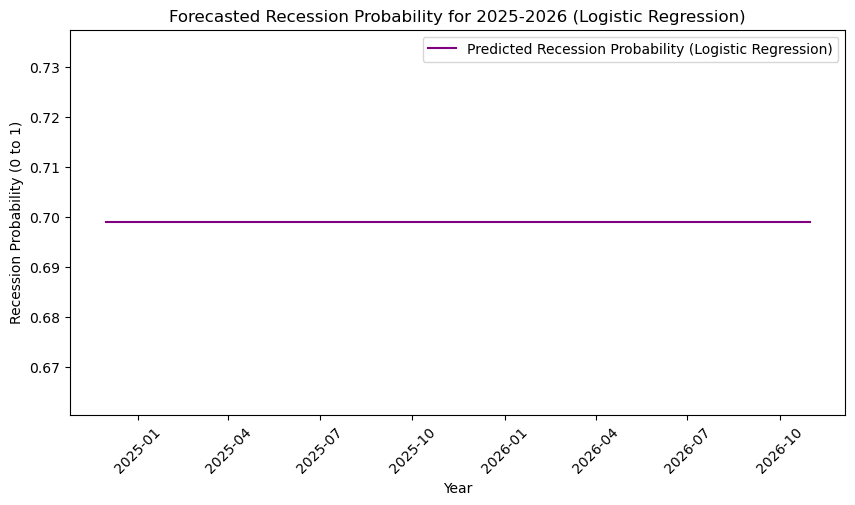

In [93]:
# Ensure feature consistency for forecasting
future_df_scaled = scaler.transform(future_df[X_train.columns])  # Scale using trained scaler

# Predict recession probability for 2025-2026
recession_prob_log = log_model.predict_proba(future_df_scaled)[:, 1]  # Get probability of recession

# Add predictions to future dataset
future_df["Recession_Probability_Logistic"] = recession_prob_log

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(future_df["DATE"], future_df["Recession_Probability_Logistic"], color='purple', label="Predicted Recession Probability (Logistic Regression)")
plt.xlabel("Year")
plt.ylabel("Recession Probability (0 to 1)")
plt.title("Forecasted Recession Probability for 2025-2026 (Logistic Regression)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

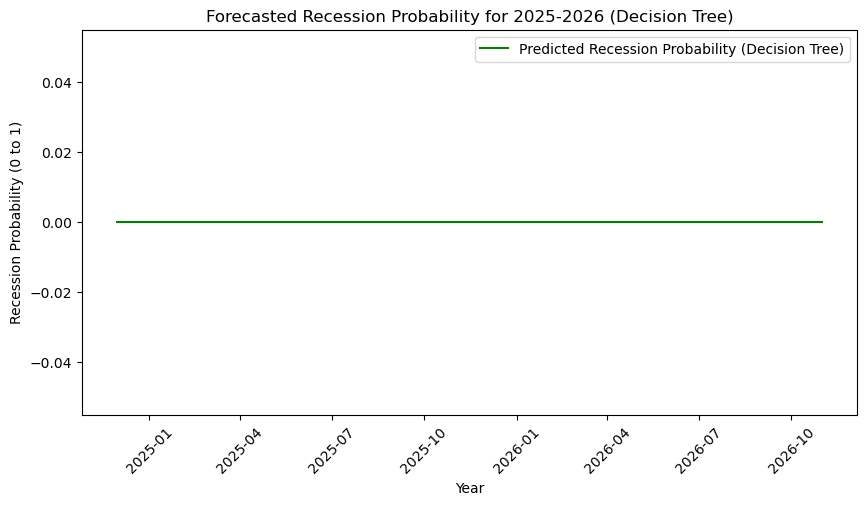

In [95]:
# Predict recession probability using Decision Tree
recession_prob_tree = dt_model.predict_proba(future_df[X_train.columns])[:, 1]  # Probability of recession

# Add predictions to future dataset
future_df["Recession_Probability_Tree"] = recession_prob_tree

# Visualization
plt.figure(figsize=(10, 5))
plt.plot(future_df["DATE"], future_df["Recession_Probability_Tree"], color='green', label="Predicted Recession Probability (Decision Tree)")
plt.xlabel("Year")
plt.ylabel("Recession Probability (0 to 1)")
plt.title("Forecasted Recession Probability for 2025-2026 (Decision Tree)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

# Comparing Models 

#### 1. Cross-Validation for Model Comparison

In [97]:
import warnings
warnings.filterwarnings("ignore")

In [99]:
from sklearn.model_selection import cross_val_score

models = {
    "Random Forest": rf_model,
    "XGBoost": xgb_model,
    "Logistic Regression": log_model,
    "Decision Tree": dt_model
}

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print(f"{name} Cross-Validation Accuracy: {scores.mean():.4f} ± {scores.std():.4f}")

Random Forest Cross-Validation Accuracy: 0.8865 ± 0.1841
XGBoost Cross-Validation Accuracy: 0.9927 ± 0.0098
Logistic Regression Cross-Validation Accuracy: 0.9534 ± 0.0389
Decision Tree Cross-Validation Accuracy: 0.9730 ± 0.0050


XGBoost outperforms all other models in terms of accuracy with the least variance.

#### 2. AUC-ROC Curve for Model Comparison

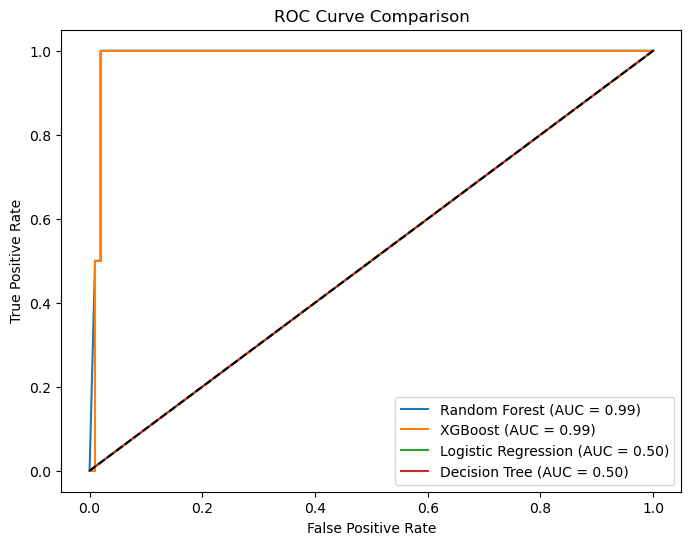

In [101]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]  # Get probability scores for class 1
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')  # Random classifier baseline
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()

XGBoost and Random Forest have the highest predictive power, while Logistic Regression and Decision Tree seem ineffective in distinguishing between recession and no-recession cases.

